# Annotate models

Runs hypergraph partitioning on every original model and its PaPILO-presolved
counterpart, writes GDX annotations to disk, then compares the two partition
assignments for each model using ARI / NMI / purity.

In [ ]:
import re
import sys
from pathlib import Path

PROJECT_ROOT = Path('../..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import MODELS, PAPILO_PRESOLVED_MODELS
from src.detection import (
    annotate_mps,
    read_annotation,
    align_partitions,
    partition_similarity,
)

# MACROS
GENERATE_MIP  = False 
MAX_MPS_MB    = 30

_suffix = "_mip_obj" if GENERATE_MIP else "_obj"

ANNOTATIONS_ORIG      = Path(f'/data/energy-system-preprocessing/annotations{_suffix}/original')
ANNOTATIONS_PRESOLVED = Path(f'/data/energy-system-preprocessing/annotations{_suffix}/presolved')
ANNOTATIONS_ORIG.mkdir(parents=True, exist_ok=True)
ANNOTATIONS_PRESOLVED.mkdir(parents=True, exist_ok=True)


def region_k(name: str) -> int | None:
    m = re.match(r'^r(\d+)_', name)
    return int(m.group(1)) if m else None


def _is_target(name: str) -> bool:
    if region_k(name) is None:
        return False
    return name.endswith("_mip_obj") if GENERATE_MIP else (name.endswith("_obj") and not name.endswith("_mip_obj"))


def _mps_mb(model_dir: Path, mps_name: str = "original.mps") -> float:
    p = model_dir / mps_name
    return p.stat().st_size / 1_048_576 if p.exists() else 0.0

## Step 1 — Annotate original models

In [ ]:
import multiprocessing as mp
import sys

def _worker(args):
    import os
    _devnull = os.open(os.devnull, os.O_WRONLY)
    os.dup2(_devnull, 1)
    os.dup2(_devnull, 2)
    os.close(_devnull)

    mps_in, k, gdx_out, project_root = args
    sys.path.insert(0, project_root)
    from src.detection.annotation import annotate_mps
    annotate_mps(mps_in, k=k, output_gdx=gdx_out)

orig_models = sorted(
    [(p, region_k(p.name)) for p in MODELS.iterdir() if _is_target(p.name)],
    key=lambda x: x[0].name,
)
print(f'{len(orig_models)} original models found')

failed_orig = []
for i, (model_dir, k) in enumerate(orig_models, 1):
    name    = model_dir.name
    mps_in  = str(model_dir / 'original.mps')
    gdx_out = str(ANNOTATIONS_ORIG / f'{name}.gdx')

    if Path(gdx_out).exists():
        print(f'[{i}/{len(orig_models)}] {name}  skipped', flush=True)
        continue

    mb = _mps_mb(model_dir)
    if MAX_MPS_MB and mb > MAX_MPS_MB:
        print(f'[{i}/{len(orig_models)}] {name}  skipped ({mb:.0f} MB > {MAX_MPS_MB} MB limit)', flush=True)
        continue

    print(f'[{i}/{len(orig_models)}] {name}  (k={k}, {mb:.1f} MB)', flush=True)
    p = mp.Process(target=_worker, args=((mps_in, k, gdx_out, str(PROJECT_ROOT)),))
    p.start()
    p.join()
    if p.exitcode != 0:
        print(f'  FAILED (exitcode={p.exitcode})')
        failed_orig.append(name)

if failed_orig:
    print(f'\n{len(failed_orig)} failed: {failed_orig}')
else:
    print(f'\nDone — {len(orig_models)} original models annotated.')

485 original models found
[1/485] r10_res168_f0.0000_t0.0192_obj  skipped
[2/485] r10_res168_f0.0000_t0.0833_obj  skipped
[3/485] r10_res168_f0.0000_t1.0000_obj  skipped
[4/485] r10_res168_f0.2500_t0.5000_obj  skipped
[5/485] r10_res168_f0.5000_t1.0000_obj  skipped
[6/485] r10_res1_f0.0000_t0.0192_cf0.75_obj  skipped
[7/485] r10_res1_f0.0000_t0.0192_obj  skipped
[8/485] r10_res1_f0.0000_t0.0833_cf0.75_obj  skipped
[9/485] r10_res1_f0.0000_t0.0833_obj  skipped
[10/485] r10_res1_f0.0000_t1.0000_cf0.75_obj  skipped
[11/485] r10_res1_f0.0000_t1.0000_obj  skipped
[12/485] r10_res1_f0.2500_t0.5000_cf0.75_obj  skipped
[13/485] r10_res1_f0.2500_t0.5000_obj  skipped
[14/485] r10_res1_f0.5000_t1.0000_cf0.75_obj  skipped
[15/485] r10_res1_f0.5000_t1.0000_obj  skipped
[16/485] r10_res24_f0.0000_t0.0192_cf0.75_obj  skipped
[17/485] r10_res24_f0.0000_t0.0192_obj  skipped
[18/485] r10_res24_f0.0000_t0.0833_cf0.75_obj  skipped
[19/485] r10_res24_f0.0000_t0.0833_obj  skipped
[20/485] r10_res24_f0.0000_

## Step 2 — Annotate presolved models

In [ ]:
presolved_models = sorted(
    [(p, region_k(p.name)) for p in PAPILO_PRESOLVED_MODELS.iterdir() if _is_target(p.name)],
    key=lambda x: x[0].name,
)
print(f'{len(presolved_models)} presolved models found')

failed_presolved = []
for i, (model_dir, k) in enumerate(presolved_models, 1):
    name    = model_dir.name
    mps_in  = str(model_dir / 'reduced.mps')
    gdx_out = str(ANNOTATIONS_PRESOLVED / f'{name}.gdx')

    if not Path(mps_in).exists():
        print(f'[{i}/{len(presolved_models)}] {name}  SKIP (no reduced.mps)', flush=True)
        continue

    if Path(gdx_out).exists():
        print(f'[{i}/{len(presolved_models)}] {name}  skipped', flush=True)
        continue

    mb = _mps_mb(model_dir, 'reduced.mps')
    if MAX_MPS_MB and mb > MAX_MPS_MB:
        print(f'[{i}/{len(presolved_models)}] {name}  skipped ({mb:.0f} MB > {MAX_MPS_MB} MB limit)', flush=True)
        continue

    print(f'[{i}/{len(presolved_models)}] {name}  (k={k}, {mb:.1f} MB)', flush=True)
    p = mp.Process(target=_worker, args=((mps_in, k, gdx_out, str(PROJECT_ROOT)),))
    p.start()
    p.join()
    if p.exitcode != 0:
        print(f'  FAILED (exitcode={p.exitcode})')
        failed_presolved.append(name)

if failed_presolved:
    print(f'\n{len(failed_presolved)} failed: {failed_presolved}')
else:
    print(f'\nDone — {len(presolved_models)} presolved models annotated.')

485 presolved models found
[1/485] r10_res168_f0.0000_t0.0192_obj  skipped
[2/485] r10_res168_f0.0000_t0.0833_obj  skipped
[3/485] r10_res168_f0.0000_t1.0000_obj  skipped
[4/485] r10_res168_f0.2500_t0.5000_obj  skipped
[5/485] r10_res168_f0.5000_t1.0000_obj  skipped
[6/485] r10_res1_f0.0000_t0.0192_cf0.75_obj  skipped
[7/485] r10_res1_f0.0000_t0.0192_obj  skipped
[8/485] r10_res1_f0.0000_t0.0833_cf0.75_obj  skipped
[9/485] r10_res1_f0.0000_t0.0833_obj  skipped
[10/485] r10_res1_f0.0000_t1.0000_cf0.75_obj  skipped
[11/485] r10_res1_f0.0000_t1.0000_obj  skipped (170 MB > 10 MB limit)
[12/485] r10_res1_f0.2500_t0.5000_cf0.75_obj  skipped (42 MB > 10 MB limit)
[13/485] r10_res1_f0.2500_t0.5000_obj  skipped (42 MB > 10 MB limit)
[14/485] r10_res1_f0.5000_t1.0000_cf0.75_obj  skipped (85 MB > 10 MB limit)
[15/485] r10_res1_f0.5000_t1.0000_obj  skipped (85 MB > 10 MB limit)
[16/485] r10_res24_f0.0000_t0.0192_cf0.75_obj  (k=10, 0.1 MB)
[17/485] r10_res24_f0.0000_t0.0192_obj  (k=10, 0.1 MB)
[18/

## Step 3 — Compare partition assignments

In [ ]:
import multiprocessing as mp
import polars as pl

BATCH_SIZE = 10
BATCH_DIR  = Path(f'/data/energy-system-preprocessing/annotations{_suffix}/comparison_batches')
BATCH_DIR.mkdir(parents=True, exist_ok=True)


def _compare_batch(batch_names, orig_dir, pre_dir, project_root, out_path):
    import gc, re, sys
    sys.path.insert(0, project_root)
    from src.detection.annotation import read_annotation
    from src.detection.compare import align_partitions, partition_similarity
    import polars as pl

    def _k(name):
        m = re.match(r'^r(\d+)_', name)
        return int(m.group(1)) if m else None

    records = []
    for name in batch_names:
        cols_orig, rows_orig = read_annotation(orig_dir / f'{name}.gdx')
        cols_pre,  rows_pre  = read_annotation(pre_dir  / f'{name}.gdx')
        alignment = align_partitions(cols_orig, rows_orig, cols_pre, rows_pre)
        sim       = partition_similarity(alignment)
        records.append({'name': name, 'k': _k(name), **alignment.to_dict(), **sim.to_dict()})
        gc.collect()

    pl.DataFrame(records).write_parquet(out_path)


paired = [
    name
    for name in sorted(p.stem for p in ANNOTATIONS_ORIG.glob('*.gdx'))
    if (ANNOTATIONS_PRESOLVED / f'{name}.gdx').exists()
]
print(f'{len(paired)} paired annotations found')

batches = [paired[i:i + BATCH_SIZE] for i in range(0, len(paired), BATCH_SIZE)]
print(f'{len(batches)} batches of up to {BATCH_SIZE}')

for idx, batch in enumerate(batches):
    out_path = BATCH_DIR / f'batch_{idx:04d}.parquet'
    if out_path.exists():
        print(f'  batch {idx:3d}/{len(batches)-1}  skipped', flush=True)
        continue

    print(f'  batch {idx:3d}/{len(batches)-1}  ({len(batch)} models)...', end=' ', flush=True)
    p = mp.Process(
        target=_compare_batch,
        args=(batch, ANNOTATIONS_ORIG, ANNOTATIONS_PRESOLVED, str(PROJECT_ROOT), str(out_path)),
    )
    p.start()
    p.join()
    if p.exitcode != 0:
        print(f'FAILED (exitcode={p.exitcode})', flush=True)
    else:
        print('done', flush=True)

210 paired annotations found
21 batches of up to 10
  batch   0/20  skipped
  batch   1/20  (10 models)... done
  batch   2/20  (10 models)... done
  batch   3/20  (10 models)... done
  batch   4/20  (10 models)... done
  batch   5/20  (10 models)... done
  batch   6/20  (10 models)... done
  batch   7/20  (10 models)... done
  batch   8/20  (10 models)... done
  batch   9/20  (10 models)... done
  batch  10/20  (10 models)... done
  batch  11/20  (10 models)... done
  batch  12/20  (10 models)... done
  batch  13/20  (10 models)... done
  batch  14/20  (10 models)... done
  batch  15/20  (10 models)... done
  batch  16/20  (10 models)... done
  batch  17/20  (10 models)... done
  batch  18/20  (10 models)... done
  batch  19/20  (10 models)... done
  batch  20/20  (10 models)... done


In [ ]:
batch_files = sorted(BATCH_DIR.glob('batch_*.parquet'))
results = pl.concat([pl.read_parquet(f) for f in batch_files])
print(f'Loaded {len(results)} results from {len(batch_files)} batches.')


Loaded 210 results from 21 batches.


## Step 4 — Summary table

In [ ]:
results.select([
    'name', 'k',
    'n_cols_a', 'n_surviving_cols', 'col_survival_rate',
    'n_rows_a', 'n_surviving_rows', 'row_survival_rate',
    'col_ari', 'col_nmi', 'col_purity',
    'row_ari', 'row_nmi', 'row_purity',
])

name,k,n_cols_a,n_surviving_cols,col_survival_rate,n_rows_a,n_surviving_rows,row_survival_rate,col_ari,col_nmi,col_purity,row_ari,row_nmi,row_purity
str,i64,i64,i64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64
"""r10_res168_f0.0000_t0.0192_obj""",10,214,193,0.901869,149,108,0.724832,0.397148,0.635867,0.569948,0.442256,0.668311,0.611111
"""r10_res168_f0.0000_t0.0833_obj""",10,638,617,0.967085,533,502,0.941839,0.289459,0.521797,0.458671,0.395286,0.614927,0.527888
"""r10_res168_f0.0000_t1.0000_obj""",10,5726,5703,0.995983,5141,5108,0.993581,0.465964,0.591855,0.63791,0.579815,0.722342,0.706735
"""r10_res168_f0.2500_t0.5000_obj""",10,1592,1568,0.984925,1397,1363,0.975662,0.267957,0.45568,0.455357,0.390973,0.58051,0.546588
"""r10_res168_f0.5000_t1.0000_obj""",10,2970,2947,0.992256,2645,2612,0.987524,0.365298,0.559904,0.515439,0.484576,0.663121,0.591118
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""r35_res168_f0.2500_t0.5000_obj""",35,5732,5650,0.985694,5036,4919,0.976767,0.346109,0.662742,0.488496,0.534195,0.716927,0.555601
"""r35_res168_f0.5000_t1.0000_obj""",35,10698,10618,0.992522,9547,9432,0.987954,0.376318,0.675705,0.510831,0.540847,0.738867,0.582061
"""r35_res24_f0.0000_t0.0192_obj""",35,3058,2908,0.950948,2607,2422,0.929037,0.306687,0.653088,0.439133,0.508431,0.689169,0.501239


## Step 5 — Plots

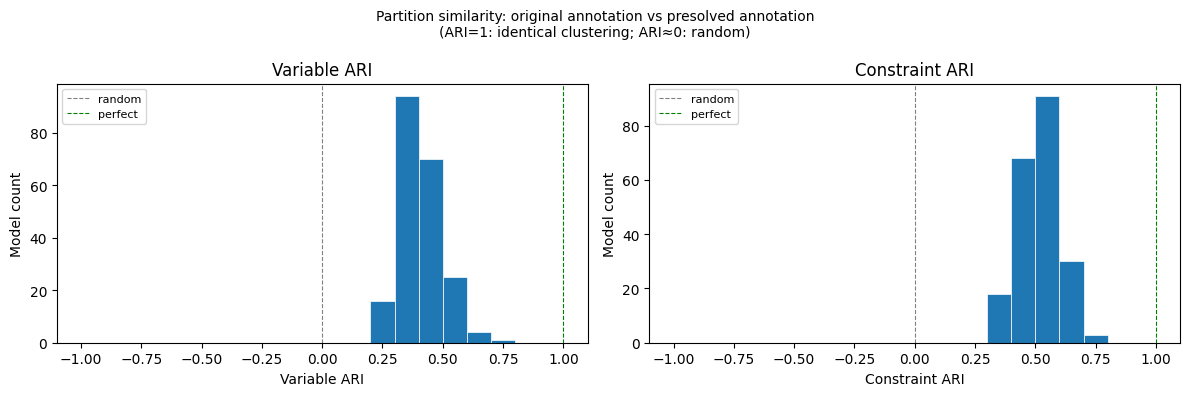

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, metric, label in [
    (axes[0], 'col_ari', 'Variable ARI'),
    (axes[1], 'row_ari', 'Constraint ARI'),
]:
    ax.hist(results[metric].to_list(), bins=20, range=(-1, 1), edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='grey',  linestyle='--', linewidth=0.8, label='random')
    ax.axvline(1, color='green', linestyle='--', linewidth=0.8, label='perfect')
    ax.set_xlabel(label)
    ax.set_ylabel('Model count')
    ax.set_title(label)
    ax.legend(fontsize=8)

fig.suptitle(
    'Partition similarity: original annotation vs presolved annotation\n'
    '(ARI=1: identical clustering; ARI≈0: random)',
    fontsize=10,
)
plt.tight_layout()
plt.show()

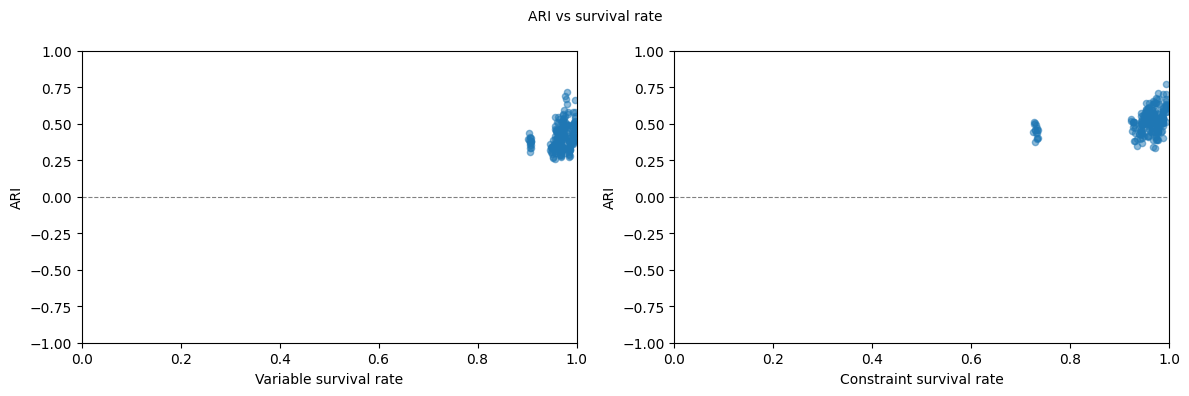

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, survival, ari, xlabel in [
    (axes[0], 'col_survival_rate', 'col_ari', 'Variable survival rate'),
    (axes[1], 'row_survival_rate', 'row_ari', 'Constraint survival rate'),
]:
    ax.scatter(results[survival].to_list(), results[ari].to_list(), alpha=0.5, s=20)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('ARI')
    ax.set_xlim(0, 1)
    ax.set_ylim(-1, 1)
    ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)

fig.suptitle('ARI vs survival rate', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
OUT = Path(f'/data/energy-system-preprocessing/annotations{_suffix}')
results.write_parquet(OUT / 'comparison_results.parquet')
print(f'Saved to {OUT / "comparison_results.parquet"}')

Saved to /data/energy-system-preprocessing/annotations_obj/comparison_results.parquet
